# Model Performance vs Reliability: A Study on Classification and Calibration

## 1. Motivation

Machine learning models are often evaluated using performance metrics such as accuracy, precision, or recall. However, these metrics alone do not capture an important aspect of model behavior: how reliable the predicted probabilities are.

In many real-world applications—especially in domains such as healthcare, finance, and autonomous systems—it is not enough for a model to be correct. It must also be well-calibrated, meaning that its predicted probabilities reflect true likelihoods.

For example:

- A model that predicts a 90% probability of disease should be correct approximately 90% of the time in such cases.
- Poor calibration can lead to overconfidence or underconfidence, both of which are problematic in decision-making systems.

## 2. Objective

This notebook investigates the relationship between model performance and probabilistic reliability by comparing:

- A linear model: Logistic Regression
- A non-linear ensemble model: Random Forest

The analysis focuses on:

- Classification performance (accuracy, precision, recall, ROC)
- Probability calibration (calibration curves, Brier score)
- Differences in model behavior and their implications

## 3. Dataset

The UCI Heart Disease Dataset is used - a widely used benchmark dataset for binary classification.

https://www.kaggle.com/datasets/redwankarimsony/heart-disease-data

The task is to predict whether a patient has heart disease based on clinical features such as:

## 4. Key Questions

This notebook aims to answer the following:

1 - How do different models compare in terms of classification performance?
2 - Do higher-performing models also produce better probability estimates?
3 - How well-calibrated are the predicted probabilities?
4 - What are the practical implications of miscalibration?

## 5. Approach Overview

The workflow is structured as follows:

1 - Data loading and preprocessing
2 - Exploratory data analysis (EDA)
3 - Model training (Logistic Regression, Random Forest)
4 - Performance evaluation
5 - Calibration analysis
6 - Critical discussion of results

## 6. Why This Matters

A model that is accurate but poorly calibrated can be actively misleading.
This is particularly important in safety-critical and human-centered AI systems, where decisions depend not just on predictions, but on trust in those predictions.

In [1]:
# =========================================
# Imports and general setup
# =========================================

# Core data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: models and evaluation
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    brier_score_loss,
)

# Reproducibility
RANDOM_STATE = 42

# Plot styling for consistency
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
# Check working directory (to get correct path to the dataset)
#import os
#print(os.getcwd())

## Data loading and initial inspection

The dataset is loaded and inspected to understand its structure, feature types, and potential quality issues such as missing values/invalid entries.

In [3]:

# Load dataset
df = pd.read_csv("../../datasets/heart_disease_uci.csv")

# Basic shape and preview
print("Dataset shape:", df.shape)
display(df.head())

# Column info and data types
print("\nColumn information:")
df.info()

# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Basic statistics (numerical features)
print("\nStatistical summary:")
display(df.describe())

Dataset shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0



Column information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB

Missing values per column:
id            0
age           0
sex           0
dataset       0
cp            0


,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


## Data cleaning and target definition

Several preprocessing steps are applied:
- Irrelevant columns (identifiers, dataset origin) are removed  
- The target variable is converted into a binary classification task  
- Implausible values (zero values for physiological measurements) are treated as missing  
- Features with excessive missing values are removed to avoid unreliable imputation 

These steps ensure that the dataset is suitable for the models, and minimizes bias introduced by poor data quality.

In [4]:

df_clean = df.copy()

# Drop irrelevant columns
df_clean = df_clean.drop(columns=["id", "dataset", "ca", "thal", "slope"], errors="ignore")

# Convert target to binary
# 0 = no disease, 1 = disease (num > 0)
df_clean["target"] = (df_clean["num"] > 0).astype(int)
df_clean = df_clean.drop(columns=["num"])

# Replace invalid zero values with NaN
# These are physiologically impossible → treat as missing
for col in ["trestbps", "chol"]:
    df_clean[col] = df_clean[col].replace(0, np.nan)

# Inspect remaining missing values
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

Missing values after cleaning:
age           0
sex           0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
target        0
dtype: int64


In [5]:
# Check class distribution (proportion of positive vs negative cases)
print(df_clean["target"].value_counts(normalize=True))

target
1    0.553261
0    0.446739
Name: proportion, dtype: float64


## Train-Test Split

The dataset is split into training and testing subsets to evaluate model generalization.  
The split is stratified to preserve class distribution across both sets.

In [6]:

X = df_clean.drop(columns=["target"])
y = df_clean["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (736, 10)
Test shape: (184, 10)


In [7]:
# Verify final feature set after cleaning (ensures no unintended columns remain)
print(X_train.columns)

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch',
       'exang', 'oldpeak'],
      dtype='object')


## Preprocessing Pipeline

A structured preprocessing pipeline is defined using `ColumnTransformer`:

- Numerical features: median imputation and standardization  
- Categorical features: most frequent imputation and one-hot encoding  

In [8]:

# Recompute feature types after dropping dataset
numerical_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "bool"]).columns.tolist()

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

# Numerical pipeline
numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine
preprocessor = ColumnTransformer(transformers=[
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

Numerical features: ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang']


## Model Pipelines

Two models are evaluated:

- Logistic Regression: a linear, interpretable baseline  
- Random Forest: a non-linear ensemble model with higher flexibility  

Both models are integrated into pipelines to ensure preprocessing is applied consistently during training and inference.

In [9]:

# Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=RANDOM_STATE
    ))
])

## Model Training

Both models are trained on the training data using the defined pipelines.  

In [20]:

logreg_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train);

## Model Evaluation

Models are evaluated using multiple metrics:

- Accuracy, Precision, Recall: classification performance  
- ROC-AUC: ranking quality independent of threshold  
- Brier Score: probability calibration  

This combination allows us to assess both predictive performance and reliability of probability estimates.

In [11]:

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n{name}")
    print("-" * 40)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))

    return y_proba


# Evaluate both models
logreg_proba = evaluate_model(logreg_pipeline, X_test, y_test, "Logistic Regression")
rf_proba = evaluate_model(rf_pipeline, X_test, y_test, "Random Forest")


Logistic Regression
----------------------------------------
Accuracy: 0.7989130434782609
Precision: 0.7927927927927928
Recall: 0.8627450980392157
ROC-AUC: 0.8916786226685797

Random Forest
----------------------------------------
Accuracy: 0.7934782608695652
Precision: 0.7962962962962963
Recall: 0.8431372549019608
ROC-AUC: 0.9082974653275945


## ROC Curve Analysis

The ROC curve illustrates the trade-off between true positive rate and false positive rate across thresholds.  
It provides insight into how well each model separates the classes.

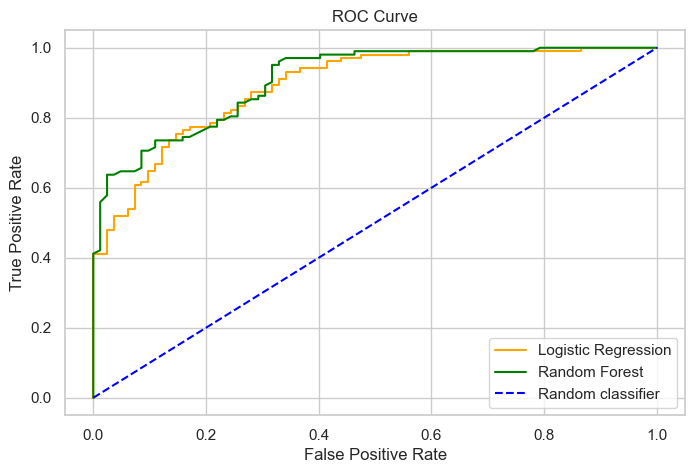

In [12]:

fpr_log, tpr_log, _ = roc_curve(y_test, logreg_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure()

# Models
plt.plot(fpr_log, tpr_log, color="orange", label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, color="green", label="Random Forest")

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="blue", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Calibration Analysis

Calibration curves compare predicted probabilities with observed outcomes.

A well-calibrated model produces probabilities that reflect true likelihoods.  
Deviations from the diagonal indicate overconfidence or underconfidence.

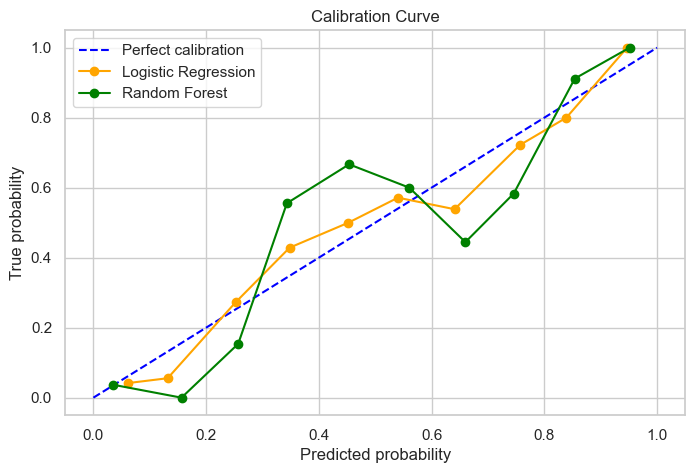

In [13]:

prob_true_log, prob_pred_log = calibration_curve(y_test, logreg_proba, n_bins=10)
prob_true_rf, prob_pred_rf = calibration_curve(y_test, rf_proba, n_bins=10)

plt.figure()

# Perfect calibration line
plt.plot([0, 1], [0, 1], linestyle="--", color="blue", label="Perfect calibration")

# Models
plt.plot(prob_pred_log, prob_true_log, marker='o', color="orange", label="Logistic Regression")
plt.plot(prob_pred_rf, prob_true_rf, marker='o', color="green", label="Random Forest")

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Curve")
plt.legend()
plt.show()

## Brier Score Evaluation

The Brier score measures the accuracy of predicted probabilities by computing the mean squared difference between predicted probabilities and actual outcomes.

Unlike metrics such as accuracy or ROC-AUC, the Brier score directly evaluates the quality of probabilistic predictions.

Lower values indicate better calibration and overall probability accuracy.

In [14]:

brier_log = brier_score_loss(y_test, logreg_proba)
brier_rf = brier_score_loss(y_test, rf_proba)

print("Brier Score (lower is better):")
print("Logistic Regression:", brier_log)
print("Random Forest:", brier_rf)

Brier Score (lower is better):
Logistic Regression: 0.13246050130620354
Random Forest: 0.1247335597826087


## Probability Distribution Analysis

This histogram shows the distribution of predicted probabilities from the Random Forest model.

It helps identify whether the model tends to produce extreme (near 0 or 1) or moderate probability estimates.

A concentration of predictions near the extremes may indicate overconfidence, which can affect calibration quality.

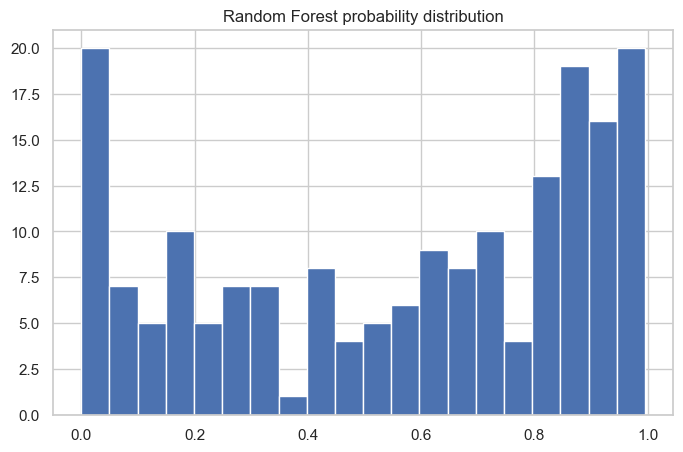

In [15]:
# Show histogram of predicted probabilities
plt.hist(rf_proba, bins=20)
plt.title("Random Forest probability distribution")
plt.show()

## Random forest - Isotonic Calibration

Isotonic calibration is a non-parametric method that fits a flexible, monotonic mapping between predicted probabilities and observed outcomes.

It can correct complex miscalibration patterns but is prone to overfitting, especially when applied to smaller datasets.

In [16]:

rf_calibrated_iso = CalibratedClassifierCV(
    estimator=rf_pipeline,
    method="isotonic",
    cv=5
)

rf_calibrated_iso.fit(X_train, y_train)

rf_isotonic_proba = rf_calibrated_iso.predict_proba(X_test)[:, 1]

prob_true_rf_cal, prob_pred_rf_cal = calibration_curve(
    y_test, rf_isotonic_proba, n_bins=10
)

## Random forest - Sigmoid Calibration (Platt Scaling)

Sigmoid calibration applies a parametric transformation using a logistic function to adjust predicted probabilities.

Compared to isotonic calibration, it is more constrained and less prone to overfitting, but may be too restrictive to correct complex calibration errors.

In [17]:

rf_calibrated_sig = CalibratedClassifierCV(
    estimator=rf_pipeline,
    method="sigmoid",
    cv=5
)

rf_calibrated_sig.fit(X_train, y_train)

# Predicted probabilities
rf_sigmoid_proba = rf_calibrated_sig.predict_proba(X_test)[:, 1]

# Calibration curve inputs
prob_true_rf_sig, prob_pred_rf_sig = calibration_curve(
    y_test, rf_sigmoid_proba, n_bins=10
)

## Calibration Comparison

Different calibration strategies are compared:

- Uncalibrated Random Forest  
- Isotonic calibration (non-parametric, flexible)  
- Sigmoid calibration (parametric, more constrained)  

This allows us to assess whether calibration improves probability reliability.

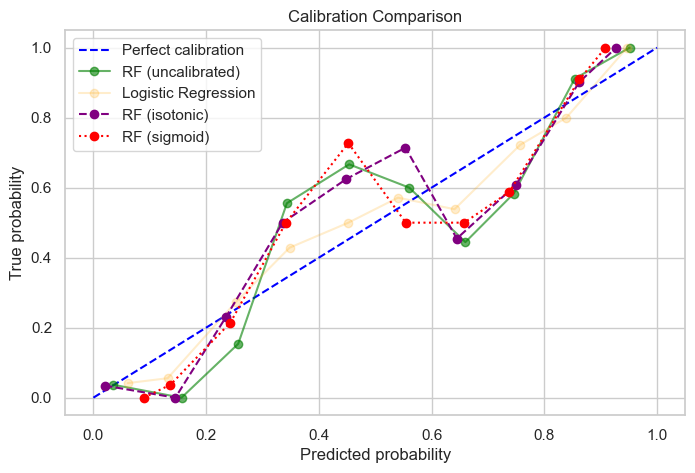

In [18]:

plt.figure()

# Reference line
plt.plot([0, 1], [0, 1], linestyle="--", color="blue", label="Perfect calibration")

# Always present
plt.plot(prob_pred_rf, prob_true_rf, marker='o', color="green", alpha=0.6, label="RF (uncalibrated)")
plt.plot(prob_pred_log, prob_true_log, marker='o', color="orange", alpha=0.2, label="Logistic Regression")

# isotonic
if "prob_pred_rf_cal" in globals():
    plt.plot(
        prob_pred_rf_cal,
        prob_true_rf_cal,
        marker='o',
        color="purple",
        linestyle="--",
        label="RF (isotonic)"
    )

# sigmoid
if "prob_pred_rf_sig" in globals():
    plt.plot(
        prob_pred_rf_sig,
        prob_true_rf_sig,
        marker='o',
        color="red",
        linestyle=":",
        label="RF (sigmoid)"
    )

plt.xlabel("Predicted probability")
plt.ylabel("True probability")
plt.title("Calibration Comparison")
plt.legend()
plt.show()

In [19]:
# =========================================
# Brier score comparison
# =========================================

print("Brier Scores:")

# Always present
print("Logistic Regression:", brier_log)
print("RF (uncalibrated):", brier_rf)

# Optional: isotonic
if "rf_isotonic_proba" in globals():
    brier_rf_iso = brier_score_loss(y_test, rf_isotonic_proba)
    print("RF (isotonic):", brier_rf_iso)

# Optional: sigmoid
if "rf_sigmoid_proba" in globals():
    brier_rf_sig = brier_score_loss(y_test, rf_sigmoid_proba)
    print("RF (sigmoid):", brier_rf_sig)

Brier Scores:
Logistic Regression: 0.13246050130620354
RF (uncalibrated): 0.1247335597826087
RF (isotonic): 0.12627111025379084
RF (sigmoid): 0.1283940649954245


## 7. Final Discussion: Calibration Results and Trade-offs

The calibration analysis reveals that applying calibration methods does not necessarily improve model reliability.

Although the Random Forest model exhibited irregularities in its calibration curve, it achieved the lowest Brier score among all models, indicating the most accurate probability estimates on average. This suggests that, despite local deviations, the model was already well-calibrated in a global sense.

Both isotonic regression and sigmoid calibration were applied to the Random Forest model. However, neither method improved performance. Isotonic calibration slightly degraded the Brier score, likely due to overfitting given the limited dataset size. Sigmoid calibration, while more stable, imposed a restrictive mapping that further reduced probability accuracy.

Logistic Regression produced smoother and more interpretable calibration curves but achieved lower predictive performance and higher Brier score. This highlights a trade-off between probability stability and predictive power.

These findings demonstrate that:

- Calibration methods are not universally beneficial
- Small datasets increase the risk of overfitting during calibration
- Visual calibration curves should be interpreted alongside aggregate metrics such as Brier score
- A model with irregular calibration may still provide more accurate probabilities overall